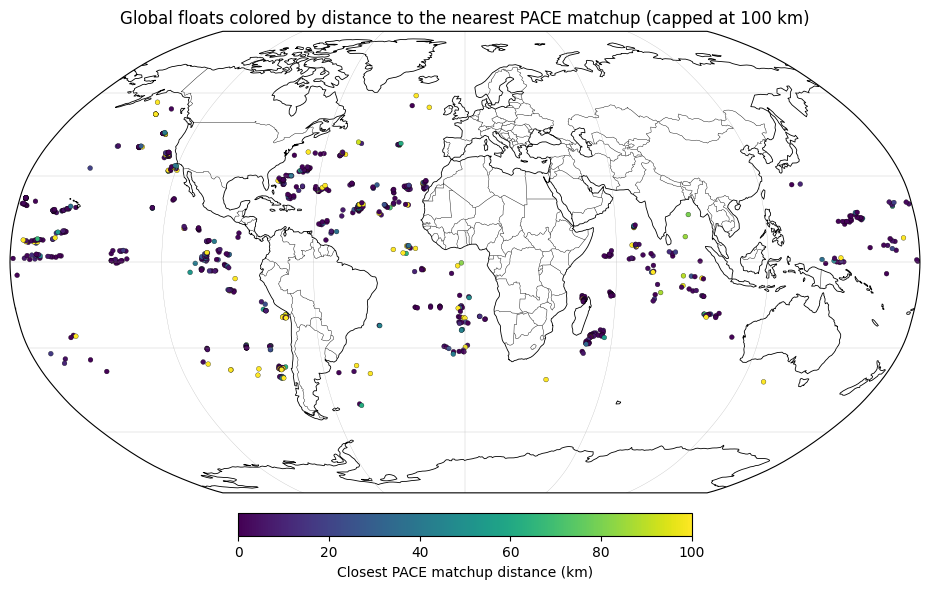

In [1]:
# === CONFIG ===
CSV_IN   = "/Users/allie/Documents/summer 2025/python/bing/papers/biomass/Analysis/matched_argo_bgc_profiles_bbp.csv"
CSV_OUT  = "float_min_distance.csv"          # per-float table to save
PNG_OUT  = "global_float_distance.png"       # map image to save
CMAP     = "viridis"
POINT_SZ = 12
VMIN, VMAX = 0.0, 100.0                      # <-- cap at 0..100 km

import pandas as pd, numpy as np, matplotlib.pyplot as plt, re

# --- Load & normalize column names ---
df = pd.read_csv(CSV_IN)
df.columns = [c.strip() for c in df.columns]
lower = {c: re.sub(r"\s+", "_", c.strip().lower()) for c in df.columns}
df.rename(columns=lower, inplace=True)

def pick(cols, pats):
    for p in pats:
        for c in cols:
            if re.search(p, c):
                return c
    return None

cols = df.columns.tolist()

# Float coords & ID
float_lat = pick(cols, [r"^float_?lat$", r"^argo_?lat$", r"^profile_?lat$", r"^lat_?float$", r"^lat$"])
float_lon = pick(cols, [r"^float_?lon$", r"^argo_?lon$", r"^profile_?lon$", r"^lon_?float$", r"^lon$"])
float_id  = pick(cols, [r"^wmo$", r"platform(_number)?$", r"^float_id$", r"^argo_id$"])

# PACE coords (only used if no distance column)
pace_lat  = pick(cols, [r"^pace_?lat$", r"^match_?lat$", r"^sat_?lat$", r"^oci_?lat$", r"^granule_?lat$", r"^l2_?lat$"])
pace_lon  = pick(cols, [r"^pace_?lon$", r"^match_?lon$", r"^sat_?lon$", r"^oci_?lon$", r"^granule_?lon$", r"^l2_?lon$"])

# Precomputed distance?
dist_col = pick(cols, [r"(distance|dist|separation).*km$", r"^(distance|dist|separation)$"])

# --- Compute great-circle distance (km) if needed ---
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 6371.0 * (2*np.arcsin(np.sqrt(a)))  # Earth radius 6371 km

if dist_col is None:
    if not (float_lat and float_lon and pace_lat and pace_lon):
        raise ValueError("Couldn't find enough columns to compute distance. "
                         "Need float & PACE lat/lon OR an existing distance column.")
    def norm_lon(x): return ((np.asarray(x, float) + 180) % 360) - 180
    df["distance_km"] = haversine_km(df[float_lat].astype(float),
                                     norm_lon(df[float_lon]),
                                     df[pace_lat].astype(float),
                                     norm_lon(df[pace_lon]))
    dist_col = "distance_km"
# --- Per-float key (prefer WMO/ID, else rounded lat/lon) ---
if float_id:
    df["_float_key"] = df[float_id].astype(str)
else:
    if not (float_lat and float_lon):
        raise ValueError("Missing float coordinates for fallback grouping.")
    df["_float_key"] = (df[float_lat].astype(float).round(2).astype(str) + "," +
                        df[float_lon].astype(float).round(2).astype(str))

# --- Reduce to one row per float: min distance + median location ---
agg = (df.groupby("_float_key")
         .agg(lat=(float_lat, "median"),
              lon=(float_lon, "median"),
              min_distance_km=(dist_col, "min"))
         .reset_index(drop=True))

# Normalize lon for plotting
agg["lon"] = ((agg["lon"] + 180) % 360) - 180

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig = plt.figure(figsize=(12,6))
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.gridlines(draw_labels=False, linewidth=0.2)

    sc = ax.scatter(agg["lon"], agg["lat"],
                    c=agg["min_distance_km"], s=POINT_SZ,
                    cmap=CMAP, vmin=VMIN, vmax=VMAX,
                    transform=ccrs.PlateCarree(),
                    edgecolors="k", linewidths=0.2)

    cb = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.04, fraction=0.045)
    cb.set_label("Closest PACE matchup distance (km)")
    plt.title("Global floats colored by distance to the nearest PACE matchup (capped at 100 km)")
    plt.tight_layout()
    plt.savefig(PNG_OUT, dpi=200)
    plt.show()

except Exception as e:
    print("(Cartopy not available; plotting without coastlines)\nReason:", e)
    plt.figure(figsize=(11,5))
    sc = plt.scatter(agg["lon"], agg["lat"],
                     c=agg["min_distance_km"], s=POINT_SZ,
                     cmap=CMAP, vmin=VMIN, vmax=VMAX,
                     edgecolors="k", linewidths=0.2)
    plt.xlim(-180, 180); plt.ylim(-90, 90)
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    cb = plt.colorbar(sc); cb.set_label("Closest PACE matchup distance (km)")
    plt.title("Global floats colored by distance to the nearest PACE matchup (capped at 100 km)")
    plt.tight_layout()
    plt.savefig(PNG_OUT, dpi=200)
    plt.show()

In [17]:


CSV_IN = "/Users/allie/Documents/summer 2025/python/bing/papers/biomass/Analysis/matched_argo_bgc_profiles_bbp.csv"

df = pd.read_csv(CSV_IN)
cols = {c.lower().strip().replace(" ", "_"): c for c in df.columns}

def pick(*pats):
    for p in pats:
        for k in cols:
            if re.search(p, k):
                return cols[k]
    return None

# Use a precomputed distance column if present; otherwise compute from float↔PACE coords like before
dist_c = pick(r"(distance|dist|separation).*km$", r"^(distance|dist|separation)$")
if dist_c is None:
    # try to compute distances
    lat_f  = pick(r"^float_?lat$", r"^argo_?lat$", r"^profile_?lat$", r"\b(lat|latitude)\b")
    lon_f  = pick(r"^float_?lon$", r"^argo_?lon$", r"^profile_?lon$", r"\b(lon|longitude)\b")
    lat_p  = pick(r"^pace_?lat$", r"^match_?lat$", r"^sat_?lat$", r"^oci_?lat$", r"^l2_?lat$")
    lon_p  = pick(r"^pace_?lon$", r"^match_?lon$", r"^sat_?lon$", r"^oci_?lon$", r"^l2_?lon$")
    if not all([lat_f, lon_f, lat_p, lon_p]):
        raise ValueError("Need a distance column or float & PACE lat/lon to compute distances.")
    def norm(x): return ((np.asarray(x, float) + 180) % 360) - 180
    def haversine_km(a1, b1, a2, b2):
        a1, b1, a2, b2 = map(np.radians, [a1, b1, a2, b2])
        dlon, dlat = b2 - b1, a2 - a1
        h = np.sin(dlat/2)**2 + np.cos(a1)*np.cos(a2)*np.sin(dlon/2)**2
        return 6371.0 * (2*np.arcsin(np.sqrt(h)))
    df["distance_km"] = haversine_km(df[lat_f], norm(df[lon_f]), df[lat_p], norm(df[lon_p]))
    dist_c = "distance_km"

d = df[dist_c].astype(float).dropna().values

# Summary stats that answer “where the majority are”
p25, p50, p75 = np.percentile(d, [25, 50, 75])
p90 = np.percentile(d, 90)
under_25  = np.mean(d <= 25)  * 100
under_50  = np.mean(d <= 50)  * 100
under_100 = np.mean(d <= 100) * 100

print(f"Total matchups: {d.size}")
print(f"Median (50th pct): {p50:.1f} km")
print(f"IQR (25th–75th): {p25:.1f}–{p75:.1f} km")
print(f"90th percentile: {p90:.1f} km")
print(f"≤ 25 km:  {under_25:5.1f}% of matchups")
print(f"≤ 50 km:  {under_50:5.1f}% of matchups")
print(f"≤ 100 km: {under_100:5.1f}% of matchups")

Total matchups: 812
Median (50th pct): 2.1 km
IQR (25th–75th): 0.6–19.4 km
90th percentile: 100.4 km
≤ 25 km:   78.1% of matchups
≤ 50 km:   84.4% of matchups
≤ 100 km:  89.9% of matchups


In [3]:
bins = np.arange(0, max(100, d.max()) + 10, 10)
hist, edges = np.histogram(d, bins=bins)
imax = hist.argmax()
print(f"Most populated bin: {edges[imax]:.0f}–{edges[imax+1]:.0f} km "
      f"({hist[imax]} matchups, {100*hist[imax]/d.size:.1f}%)")

Most populated bin: 0–10 km (565 matchups, 69.6%)


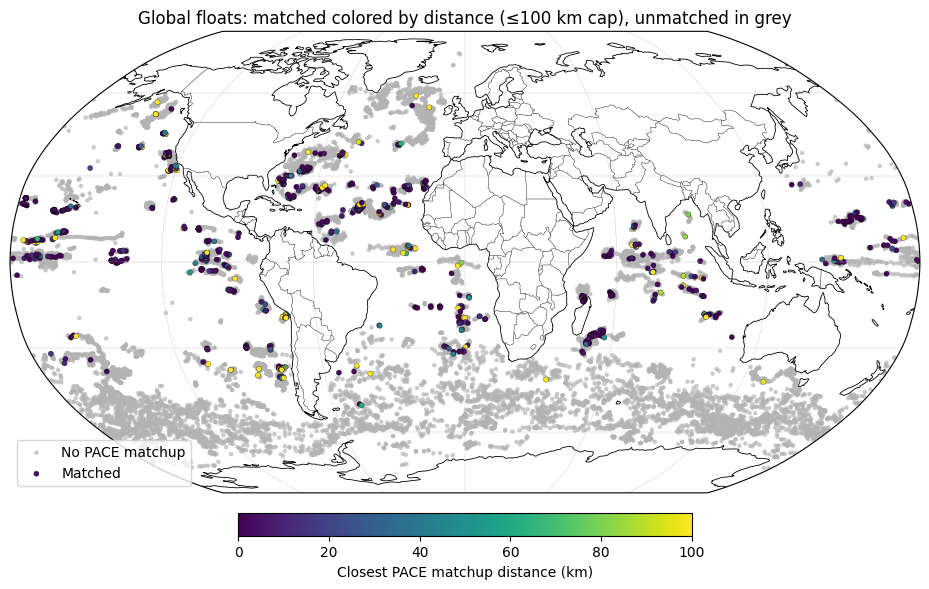

Matched floats plotted:  786
Unmatched floats plotted: 15716


In [11]:
# --- INPUTS: set your two files ---
CSV_MATCHED = "/Users/allie/Documents/summer 2025/python/bing/papers/biomass/Analysis/matched_argo_bgc_profiles_bbp.csv"
CSV_ALL     = "/Users/allie/Documents/summer 2025/python/bing/papers/biomass/Analysis/argo_bgc_profiles_bbp.csv"

# --- CONFIG ---
CAP_KM   = 100.0      # cap color scale at 0..100 km
CMAP     = "viridis"  # colormap for matched points
DOT_ALL  = 10         # size of grey "all floats"
DOT_MATCH= 14         # size of colored "matched (min dist)"

import pandas as pd, numpy as np, matplotlib.pyplot as plt, re

def read_and_normalize(path):
    df = pd.read_csv(path)
    norm = {c: re.sub(r"\s+","_",c.strip().lower()) for c in df.columns}
    df.rename(columns=norm, inplace=True)
    return df

def pick(df, *pats):
    cols = df.columns
    for pat in pats:
        rgx = re.compile(pat, re.I)
        for c in cols:
            if rgx.search(c): return c
    return None

def norm_lon(x): return ((np.asarray(x, float) + 180) % 360) - 180

# --- load full float table (ALL) ---
all_df = read_and_normalize(CSV_ALL)
lat_all = pick(all_df, r"^float_?lat$", r"^argo_?lat$", r"^profile_?lat$", r"(^|_)lat(itude)?$")
lon_all = pick(all_df, r"^float_?lon$", r"^argo_?lon$", r"^profile_?lon$", r"(^|_)lon(gitude)?$")
id_all  = pick(all_df, r"^wmo$", r"platform(_number)?$", r"^float_id$", r"^argo_id$")

if id_all:
    all_per_float = (all_df
                     .groupby(id_all)
                     .agg(lat=(lat_all,"median"), lon=(lon_all,"median"))
                     .reset_index())
else:
    # fallback: group by rounded lat/lon (≈0.02°)
    all_df["_key"] = all_df[lat_all].round(2).astype(str)+","+all_df[lon_all].round(2).astype(str)
    all_per_float = (all_df.groupby("_key")
                     .agg(lat=(lat_all,"median"), lon=(lon_all,"median"))
                     .reset_index(drop=True))

all_per_float["lon"] = norm_lon(all_per_float["lon"])

# --- load matched table (MATCHED) and reduce per float with min distance ---
m = read_and_normalize(CSV_MATCHED)
lat_m = pick(m, r"^float_?lat$", r"^argo_?lat$", r"^profile_?lat$", r"(^|_)lat(itude)?$")
lon_m = pick(m, r"^float_?lon$", r"^argo_?lon$", r"^profile_?lon$", r"(^|_)lon(gitude)?$")
id_m  = pick(m, r"^wmo$", r"platform(_number)?$", r"^float_id$", r"^argo_id$")
dist  = pick(m, r"(distance|dist|separation).*km$", r"^(distance|dist|separation)_?km$", r"^(distance|dist|separation)$")
if dist is None:
    raise ValueError("Couldn't find a distance column (km) in the matched CSV.")

if id_m:
    matched_per_float = (m.groupby(id_m)
                           .agg(lat=(lat_m,"median"),
                                lon=(lon_m,"median"),
                                min_distance_km=(dist,"min"))
                           .reset_index())
    # figure out which floats are unmatched (present in ALL but not in MATCHED)
    matched_ids = set(matched_per_float[id_m].astype(str))
    all_per_float["_id"] = (all_df[id_all].astype(str).drop_duplicates().values
                            if id_all else np.arange(len(all_per_float)))
else:
    # no IDs → define per-float key by rounded lat/lon to identify matched set
    m["_key"] = m[lat_m].round(2).astype(str)+","+m[lon_m].round(2).astype(str)
    matched_per_float = (m.groupby("_key")
                           .agg(lat=(lat_m,"median"),
                                lon=(lon_m,"median"),
                                min_distance_km=(dist,"min"))
                           .reset_index())
    all_per_float["_key"] = all_per_float["lat"].round(2).astype(str)+","+all_per_float["lon"].round(2).astype(str)

matched_per_float["lon"] = norm_lon(matched_per_float["lon"])

# --- compute unmatched floats (present in ALL but not in MATCHED) ---
if id_m and id_all:
    all_ids = set(all_df[id_all].astype(str).unique())
    unmatched_ids = list(all_ids - matched_ids)
    # build positions for unmatched (median per float)
    unmatched = (all_df[all_df[id_all].astype(str).isin(unmatched_ids)]
                 .groupby(id_all)
                 .agg(lat=(lat_all,"median"), lon=(lon_all,"median"))
                 .reset_index())
    unmatched["lon"] = norm_lon(unmatched["lon"])
else:
    matched_keys = set(matched_per_float.get("_key", 
                     (matched_per_float["lat"].round(2).astype(str)+","+matched_per_float["lon"].round(2).astype(str))).values)
    all_keys = set(all_per_float.get("_key",
                 (all_per_float["lat"].round(2).astype(str)+","+all_per_float["lon"].round(2).astype(str))).values)
    diff_keys = list(all_keys - matched_keys)
    mask = all_per_float.get("_key",
           (all_per_float["lat"].round(2).astype(str)+","+all_per_float["lon"].round(2).astype(str))).isin(diff_keys)
    unmatched = all_per_float.loc[mask, ["lat","lon"]].copy()

# --- PLOT: grey unmatched under colored matched (capped at 100 km) ---
VMIN, VMAX = 0.0, CAP_KM

try:
    import cartopy.crs as ccrs, cartopy.feature as cfeature
    fig = plt.figure(figsize=(12,6))
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global(); ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.gridlines(draw_labels=False, linewidth=0.2)

    # draw unmatched first (grey)
    ax.scatter(unmatched["lon"], unmatched["lat"], s=DOT_ALL, c="0.7",
               transform=ccrs.PlateCarree(), edgecolors="none", alpha=0.7, label="No PACE matchup")

    # draw matched on top (colored by distance)
    sc = ax.scatter(matched_per_float["lon"], matched_per_float["lat"],
                    c=np.clip(matched_per_float["min_distance_km"].astype(float), VMIN, VMAX),
                    s=DOT_MATCH, cmap=CMAP, vmin=VMIN, vmax=VMAX,
                    transform=ccrs.PlateCarree(), edgecolors="k", linewidths=0.2, label="Matched")

    cb = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.04, fraction=0.045)
    cb.set_label("Closest PACE matchup distance (km)")

    plt.title("Global floats: matched colored by distance (≤100 km cap), unmatched in grey")
    plt.legend(loc="lower left")
    plt.tight_layout(); plt.show()

except Exception as e:
    print("(Cartopy not available", e)
    plt.figure(figsize=(11,5))
    plt.scatter(unmatched["lon"], unmatched["lat"], s=DOT_ALL, c="0.7", edgecolors="none", alpha=0.7, label="No PACE matchup")
    sc = plt.scatter(matched_per_float["lon"], matched_per_float["lat"],
                     c=np.clip(matched_per_float["min_distance_km"].astype(float), VMIN, VMAX),
                     s=DOT_MATCH, cmap=CMAP, vmin=VMIN, vmax=VMAX, edgecolors="k", linewidths=0.2, label="Matched")
    plt.xlim(-180, 180); plt.ylim(-90, 90)
    cb = plt.colorbar(sc); cb.set_label("Closest PACE matchup distance (km)")
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.title("Global floats: matched colored by distance (≤100 km cap), unmatched in grey")
    plt.legend(loc="lower left")
    plt.tight_layout(); plt.show()

print(f"Matched floats plotted:  {len(matched_per_float)}")
print(f"Unmatched floats plotted: {len(unmatched)}")

Plottable matchups: 811   Relative Δbbp range (clipped): [-1.00, 1.00]
Saved merged table → /Users/allie/Documents/summer 2025/python/bing/papers/biomass/Analysis/matched_with_argo_bbp_relpace_first3.csv


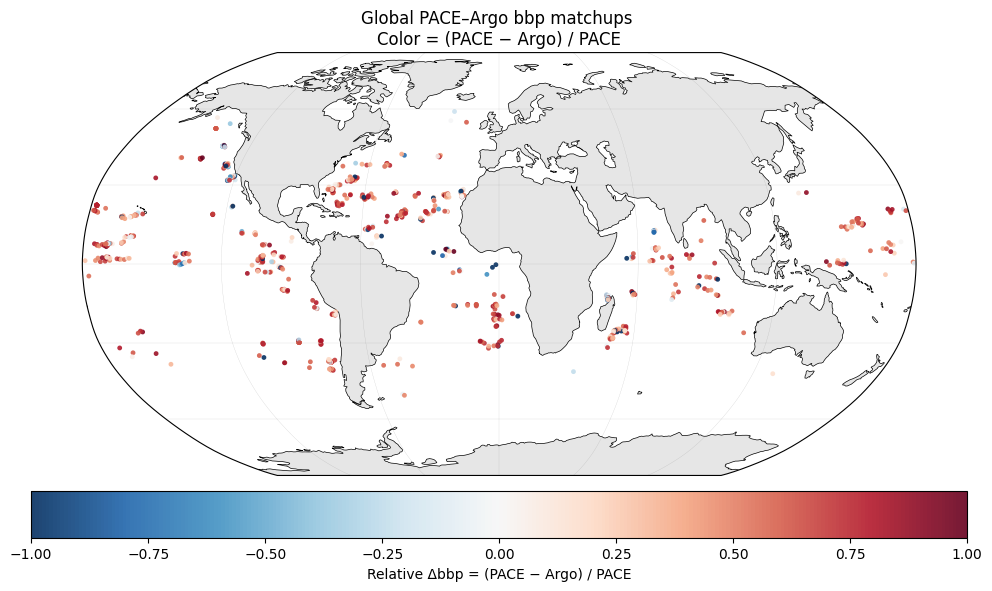

In [18]:


# -------- paths (edit if needed) --------
ROOT = Path.home() / "Documents" / "summer 2025" / "python" / "bing" / "papers" / "biomass" / "Analysis"
CSV_MATCHED = ROOT / "matched_argo_bgc_profiles_bbp.csv"          # PACE 'Bnw' + cruise/profile + lat/lon
CSV_ARGO    = ROOT / "bbp_first3_by_float_profile.csv"            # Argo first-3 mean bbp

# -------- load & normalize column names --------
m = pd.read_csv(CSV_MATCHED)
a = pd.read_csv(CSV_ARGO)
m.columns = [re.sub(r"\s+","_", c.strip().lower()) for c in m.columns]
a.columns = [re.sub(r"\s+","_", c.strip().lower()) for c in a.columns]

# --- explicit PACE column ---
PACE_BBP_COL = "bnw"   # PACE bbp column (lower-case after normalization)
if PACE_BBP_COL not in m.columns:
    raise KeyError(f"'{PACE_BBP_COL}' not found in matched CSV. Got: {m.columns.tolist()}")


# Prepare PACE table (rename cruise/profile to numeric types)
m2 = m[["cruise","profile", PACE_BBP_COL, "lat","lon"]].copy()
m2["cruise"]  = pd.to_numeric(m2["cruise"], errors="coerce").astype("Int64")
m2["profile"] = pd.to_numeric(m2["profile"], errors="coerce").astype("Int64")

# Prepare Argo table (first-3 mean bbp700)
a2 = a[["wmo","profile","bbp700_first3_mean"]].copy()
a2["wmo"]     = pd.to_numeric(a2["wmo"], errors="coerce").astype("Int64")
a2["profile"] = pd.to_numeric(a2["profile"], errors="coerce").astype("Int64")

# --- join on WMO + profile (cycle) ---
mm = (m2.rename(columns={"cruise":"wmo"})  # now keys are wmo + profile on both sides
         .merge(a2, on=["wmo","profile"], how="inner", suffixes=("_pace","_argo")))


# --- coordinates & values ---
lat = pd.to_numeric(mm["lat"], errors="coerce")
lon = pd.to_numeric(mm["lon"], errors="coerce")
pace_bbp = pd.to_numeric(mm[PACE_BBP_COL], errors="coerce")             # PACE Bnw
argo_bbp = pd.to_numeric(mm["bbp700_first3_mean"], errors="coerce")     # Argo first-3 mean

# Avoid divide-by-zero / negative PACE (bbp should be >0, but be safe)
valid = (lat.notna() & lon.notna() &
         pace_bbp.notna() & argo_bbp.notna() &
         (pace_bbp > 0))
mm = mm.loc[valid].copy()

mm["_lat"] = lat.loc[valid].values
mm["_lon"] = lon.loc[valid].values
mm["rel_dbbp"] = (pace_bbp.loc[valid] - argo_bbp.loc[valid]) / pace_bbp.loc[valid]

# Wrap lon to [-180,180] and clip to keep colorbar readable
mm["_lon"] = ((mm["_lon"] + 180) % 360) - 180
mm["rel_dbbp"] = mm["rel_dbbp"].clip(-1, 1)

print(f"Plottable matchups: {len(mm)}   Relative Δbbp range (clipped): [{mm['rel_dbbp'].min():.2f}, {mm['rel_dbbp'].max():.2f}]")

# --- save merged table for later use ---
OUT_MERGED = ROOT / "matched_with_argo_bbp_relpace_first3.csv"
(mm[["wmo","profile","_lat","_lon", PACE_BBP_COL,"bbp700_first3_mean","rel_dbbp"]]
 .rename(columns={"_lat":"lat","_lon":"lon"})
 .to_csv(OUT_MERGED, index=False))
print(f"Saved merged table → {OUT_MERGED}")

# plot
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig = plt.figure(figsize=(12,6))
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=1)
    ax.gridlines(draw_labels=False, linewidth=0.2, color="gray", alpha=0.4)

    sc = ax.scatter(mm["_lon"], mm["_lat"], c=mm["rel_dbbp"], s=12,
                    cmap="RdBu_r", vmin=-1, vmax=1,
                    transform=ccrs.PlateCarree(), linewidths=0, alpha=0.9)

    cb = plt.colorbar(sc, orientation="horizontal", pad=0.03, shrink=0.8)
    cb.set_label("Relative Δbbp = (PACE − Argo) / PACE")

    ax.set_title("Global PACE–Argo bbp matchups \nColor = (PACE − Argo) / PACE", fontsize=12)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Cartopy plot failed ({e}).")
    plt.figure(figsize=(10,5))
    plt.scatter(mm["_lon"], mm["_lat"], c=mm["rel_dbbp"], s=12,
                cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(label="Relative Δbbp = (PACE − Argo) / PACE")
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.title("PACE–Argo bbp matchups")
    plt.tight_layout()
    plt.show()

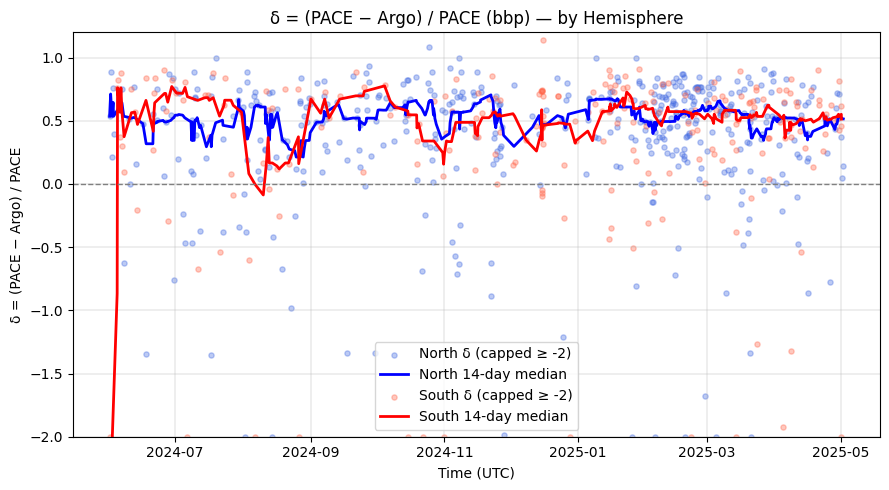

In [13]:
# === δ over time by hemisphere (scatter floored at −2), saved to Analysis ===
# δ = (PACE − Argo) / PACE  |  PACE = Bnw, Argo = bbp_first3_mean

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.dates import DateFormatter, AutoDateLocator

# -------- paths & settings --------
CSV_PATH = Path("matched_with_first3_added.csv")  # change if your CSV lives elsewhere

PACE_COL, ARGO_COL = "Bnw", "bbp_first3_mean"
LAT_COLS = ["_lat", "lat", "latitude"]
TIME_COLS = ["profile_time", "_time", "time", "datetime", "timestamp", "time_start"]
START_DATE = pd.Timestamp("2024-06-01", tz="UTC")
ROLL_DAYS = 14

# -------- helpers --------
def pick(df, cands):
    for c in cands:
        if c in df.columns:
            return c
        for col in df.columns:
            if col.lower() == c.lower():
                return col
    raise KeyError(f"Need one of {cands}; have {list(df.columns)}")

# -------- load & compute δ --------
df = pd.read_csv(CSV_PATH)
tcol = pick(df, TIME_COLS)
latcol = pick(df, LAT_COLS)

df[tcol] = pd.to_datetime(df[tcol], errors="coerce", utc=True)
df = df.dropna(subset=[tcol, latcol])

PACE = pd.to_numeric(df[PACE_COL], errors="coerce")
ARGO = pd.to_numeric(df[ARGO_COL], errors="coerce")
df["delta"] = (PACE - ARGO) / PACE

# validity: finite δ and sensible PACE>0
df = df[np.isfinite(df["delta"]) & (PACE > 0)]
df = df[df[tcol] >= START_DATE].sort_values(tcol)

# split by hemisphere
north = df[df[latcol] >= 0].copy()
south = df[df[latcol] < 0].copy()

# rolling medians (UNcapped)
roll_n = north.set_index(tcol)["delta"].rolling(f"{ROLL_DAYS}D").median()
roll_s = south.set_index(tcol)["delta"].rolling(f"{ROLL_DAYS}D").median()

# ---- Plot: cap only the scatter at -2 for readability ----
fig, ax = plt.subplots(figsize=(9,5))

north_cap = np.maximum(north["delta"].values, -2.0)
south_cap = np.maximum(south["delta"].values, -2.0)

ax.scatter(north[tcol], north_cap, s=14, alpha=0.35, color="royalblue", label="North δ (capped ≥ -2)")
ax.plot(roll_n.index, roll_n.values, color="blue", lw=2, label=f"North {ROLL_DAYS}-day median")

ax.scatter(south[tcol], south_cap, s=14, alpha=0.35, color="tomato", label="South δ (capped ≥ -2)")
ax.plot(roll_s.index, roll_s.values, color="red", lw=2, label=f"South {ROLL_DAYS}-day median")

ax.axhline(0, ls="--", lw=1, color="gray")
ax.set_title(r"δ = (PACE − Argo) / PACE (bbp) — by Hemisphere")
ax.set_ylabel("δ = (PACE − Argo) / PACE")
ax.set_xlabel("Time (UTC)")
ax.xaxis.set_major_locator(AutoDateLocator())
ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
ax.grid(True, lw=0.3)
ax.legend()

# y-limits: floor at -2, auto upper bound with a little headroom
upper = max(df["delta"].quantile(0.99), 1.2)
ax.set_ylim(-2, upper)

plt.tight_layout()
plt.show()

Strict matchups (<50 km & <3 h): 68


/var/folders/54/5kc2y0693j37p_j3_04pyxkc0000gn/T/ipykernel_60857/2381551047.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 0.95])


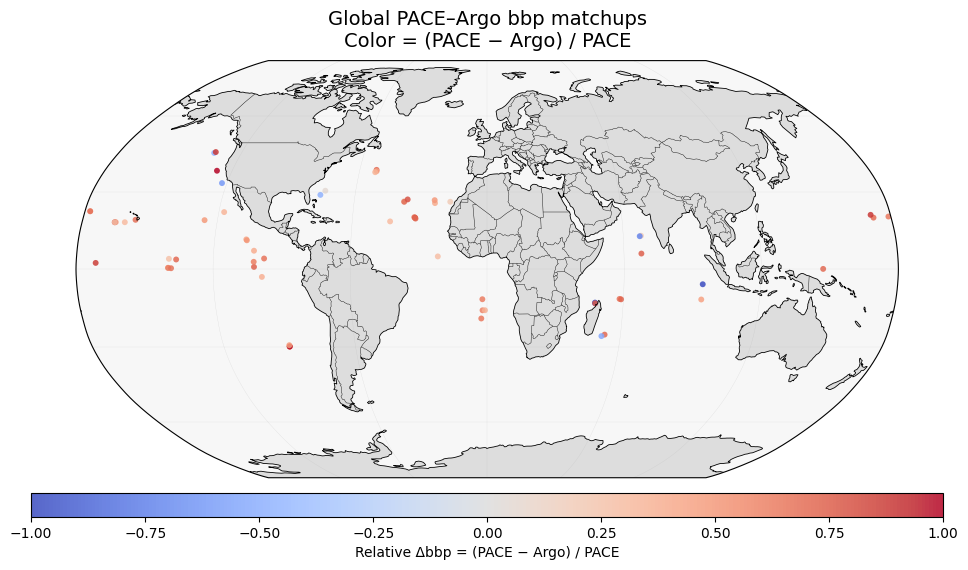

In [14]:
CSV_PATH = Path("matched_with_first3_added.csv")

PACE_COL   = "Bnw"                 # PACE bbp
ARGO_COL   = "bbp_first3_mean"     # Argo surface bbp
LAT_COL    = "lat"
LON_COL    = "lon"
DIST_COL   = "closest_dist_km"     # km
ARGO_TIME  = "time"                # Argo timestamp (UTC)
PACE_TIME  = "closest_time"        # PACE timestamp (UTC)

STRICT_DIST_KM = 50
STRICT_TDIFF_H = 3
VMIN, VMAX = -1.0, 1.0

# ---- load & prep ----
df = pd.read_csv(CSV_PATH)

# parse times and compute |Δt| (hours)
df[ARGO_TIME] = pd.to_datetime(df[ARGO_TIME], errors="coerce", utc=True)
df[PACE_TIME] = pd.to_datetime(df[PACE_TIME], errors="coerce", utc=True)
df["time_diff_hr"] = (df[ARGO_TIME] - df[PACE_TIME]).abs().dt.total_seconds() / 3600.0

# numerics
for col in [PACE_COL, ARGO_COL, LAT_COL, LON_COL, DIST_COL, "time_diff_hr"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# δ = (PACE − Argo)/PACE
df["delta"] = (df[PACE_COL] - df[ARGO_COL]) / df[PACE_COL]

# validity + STRICT filters
valid = (
    np.isfinite(df["delta"]) &
    (df[PACE_COL] > 0) &
    np.isfinite(df[LAT_COL]) & np.isfinite(df[LON_COL]) &
    np.isfinite(df[DIST_COL]) & np.isfinite(df["time_diff_hr"])
)
strict = df.loc[
    valid & (df[DIST_COL] < STRICT_DIST_KM) & (df["time_diff_hr"] < STRICT_TDIFF_H)
].copy()

print(f"Strict matchups (<{STRICT_DIST_KM} km & <{STRICT_TDIFF_H} h): {len(strict)}")

# ---- plot (Robinson) ----
proj_map = ccrs.Robinson()
proj_data = ccrs.PlateCarree()

fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=proj_map)
ax.set_global()

# background & features to match your style
ax.add_feature(cfeature.LAND.with_scale("110m"), facecolor="#dddddd")
ax.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor="#f7f7f7")
ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=False, linewidth=0.2, alpha=0.4)

# scatter (consistent color scale; data not clipped, only color saturates at [-1,1])
sc = ax.scatter(
    strict[LON_COL], strict[LAT_COL],
    c=strict["delta"], s=18, alpha=0.85, transform=proj_data,
    cmap="coolwarm", vmin=VMIN, vmax=VMAX, edgecolor="none"
)

# titles like your example
plt.title("Global PACE–Argo bbp matchups\nColor = (PACE − Argo) / PACE", fontsize=14, pad=10)

# big horizontal colorbar below
cax = fig.add_axes([0.12, 0.08, 0.76, 0.04])  # [left, bottom, width, height]
cb = plt.colorbar(sc, cax=cax, orientation="horizontal")
cb.set_label("Relative Δbbp = (PACE − Argo) / PACE")

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.show()


Total valid PACE–Argo matchups: 811


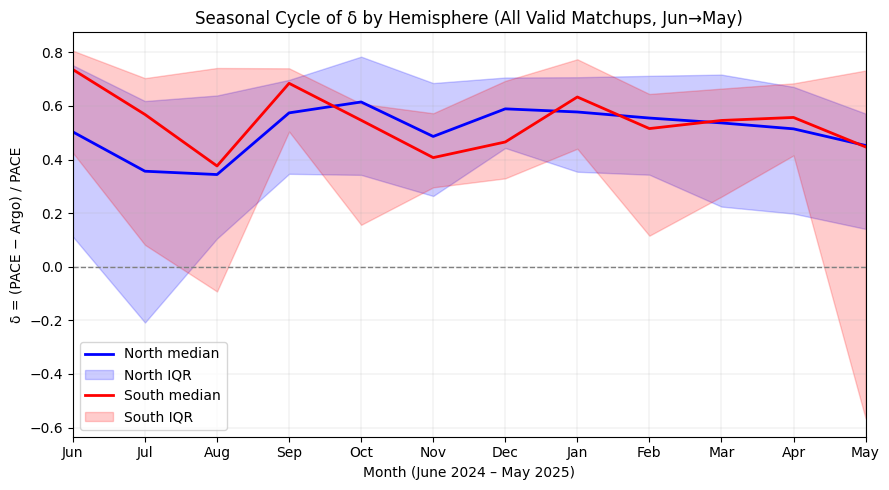


Counts per month (all matchups, Jun→May):
hemi   North  South
month              
Jun       19     10
Jul       19     13
Aug       32     12
Sep       26      8
Oct       22      9
Nov       29     18
Dec        9     27
Jan       35     31
Feb      108     26
Mar       68     36
Apr       60     44
May       29     10


In [16]:
CSV_PATH = Path("matched_with_first3_added.csv")

PACE_COL, ARGO_COL = "Bnw", "bbp_first3_mean"
LAT_COL, LON_COL   = "lat", "lon"
ARGO_TIME, PACE_TIME = "time", "closest_time"

# Load
df = pd.read_csv(CSV_PATH)
df[ARGO_TIME] = pd.to_datetime(df[ARGO_TIME], errors="coerce", utc=True)
df[PACE_TIME] = pd.to_datetime(df[PACE_TIME], errors="coerce", utc=True)
for col in [PACE_COL, ARGO_COL, LAT_COL, LON_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# δ
df["delta"] = (df[PACE_COL] - df[ARGO_COL]) / df[PACE_COL]

# Valid rows
valid = np.isfinite(df["delta"]) & np.isfinite(df[LAT_COL]) & np.isfinite(df[LON_COL]) & (df[PACE_COL] > 0)
df = df.loc[valid].copy()
print(f"Total valid PACE–Argo matchups: {len(df)}")

# Month + hemisphere
df["month"] = df[PACE_TIME].dt.month
df["hemi"]  = np.where(df[LAT_COL] >= 0, "North", "South")

# Monthly stats per hemisphere
g = (df.groupby(["hemi","month"])["delta"]
       .agg(median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75))
       .reset_index())

# Reorder months: June → May
month_order  = [6,7,8,9,10,11,12,1,2,3,4,5]
month_labels = ['Jun','Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr','May']
order_idx = pd.Index(month_order, name="month")
def reindex_hemi(sub):
    sub = sub.set_index("month").reindex(order_idx).reset_index()
    return sub

gN = reindex_hemi(g[g["hemi"]=="North"].drop(columns="hemi")).assign(hemi="North")
gS = reindex_hemi(g[g["hemi"]=="South"].drop(columns="hemi")).assign(hemi="South")
g  = pd.concat([gN, gS], ignore_index=True)

# Plot
fig, ax = plt.subplots(figsize=(9,5))
for hemi, color in [("North","blue"), ("South","red")]:
    gg = g[g["hemi"]==hemi]
    ax.plot(range(1,13), gg["median"], lw=2, color=color, label=f"{hemi} median")
    ax.fill_between(range(1,13), gg["q25"], gg["q75"], color=color, alpha=0.20, label=f"{hemi} IQR")

ax.axhline(0, ls="--", color="gray", lw=1)
ax.set_xlim(1,12)
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels)
ax.set_xlabel("Month (June 2024 – May 2025)")
ax.set_ylabel("δ = (PACE − Argo) / PACE")
ax.set_title("Seasonal Cycle of δ by Hemisphere (All Valid Matchups, Jun→May)")
ax.grid(True, lw=0.3, alpha=0.6)
ax.legend()

plt.tight_layout()
plt.show()

# Optional: coverage table in Jun→May order
counts = df.groupby(["hemi","month"]).size().unstack(0, fill_value=0).reindex(month_order)
print("\nCounts per month (all matchups, Jun→May):")
print(counts.rename(index=dict(zip(month_order, month_labels))))